In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
sns.set(font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

In [8]:
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

## PODSTAWOWE INFORMACJE O ZBIORZE:

In [24]:
print('--- Próbka danych ---')
display(df.head(50)) 

print('\n--- Informacje o zbiorze danych ---')
df.info()

print('\n--- Sprawdzenie braków danych ---')
display(df.isnull().sum())

print('\n--- Podstawowe statystyki opisowe ---')
display(df.describe().T)

--- Próbka danych ---


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.90,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.10,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.30,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.90,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.70,116,0,0,8,1
5,90.0,1,47,0,40,1,204000.00,2.10,132,1,1,8,1
6,75.0,1,246,0,15,0,127000.00,1.20,137,1,0,10,1
7,60.0,1,315,1,60,0,454000.00,1.10,131,1,1,10,1
8,65.0,0,157,0,65,0,263358.03,1.50,138,0,0,10,1
9,80.0,1,123,0,35,1,388000.00,9.40,133,1,1,10,1



--- Informacje o zbiorze danych ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
mem

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


--- Podstawowe statystyki opisowe ---


,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0



### 📖 Słownik zmiennych
Opis parametrów klinicznych pozwalający na lepsze zrozumienie danych:

| Kolumna | Opis merytoryczny | Jednostka / Wartości | Kontekst medyczny (Kluczowe wnioski) |
| :--- | :--- | :--- | :--- |
| **age** | Wiek pacjenta | lata | Podstawowy czynnik ryzyka; wiek podany w latach. |
| **anaemia** | Niedokrwistość (anemia) | 0: Nie, 1: Tak | Spadek liczby czerwonych krwinek lub hemoglobiny. |
| **creatinine_phosphokinase** | Poziom kinazy fosfokreatynowej (CPK) | **mcg/L** | Enzym mierzący uszkodzenie mięśni, w tym serca. |
| **diabetes** | Cukrzyca | 0: Nie, 1: Tak | Czy u pacjenta zdiagnozowano cukrzycę. |
| **ejection_fraction** | Frakcja wyrzutowa (EF) | **%** | Procent krwi opuszczającej serce przy każdym skurczu. |
| **high_blood_pressure** | Nadciśnienie tętnicze | 0: Nie, 1: Tak | Czy u pacjenta występuje nadciśnienie tętnicze. |
| **platelets** | Liczba płytek krwi (trombocytów) | **kilopłytki/mL** | Kluczowe dla procesów krzepnięcia krwi. |
| **serum_creatinine** | Poziom kreatyniny w surowicy | **mg/dL** | Najważniejszy marker wydolności nerek. |
| **serum_sodium** | Poziom sodu w surowicy | **mEq/L** | Marker równowagi elektrolitowej organizmu. |
| **sex** | Płeć pacjenta | 0: Kobieta, 1: Mężczyzna | Klasyfikacja binarna płci biologicznej. |
| **smoking** | Palenie tytoniu | 0: Nie, 1: Tak | Czy pacjent jest osobą palącą papierosy. |
| **time** | Okres obserwacji | **dni** | Liczba dni od rozpoczęcia do końca obserwacji pacjenta. |
| **DEATH_EVENT** | Status przeżycia (Zdarzenie) | 0: Przeżył, 1: Zmarł | Zmienna celu: zgon pacjenta w okresie obserwacji. |




--- Analiza zdarzenia (DEATH_EVENT) ---
Liczba zgonów (zdarzenie = 1): 96 (32.1%)
Liczba obserwacji cenzurowanych (zdarzenie = 0): 203 (67.9%)


C:\Users\matma\AppData\Local\Temp\ipykernel_30752\2311144628.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='DEATH_EVENT', palette='viridis')


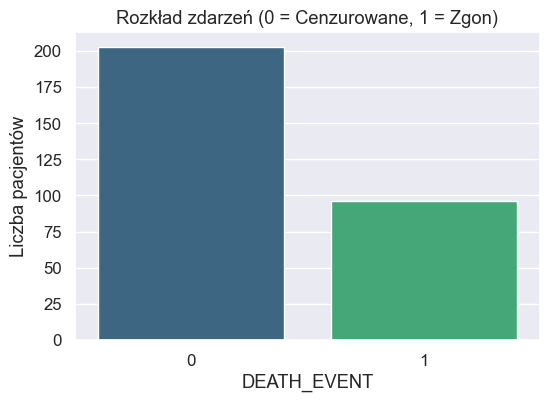

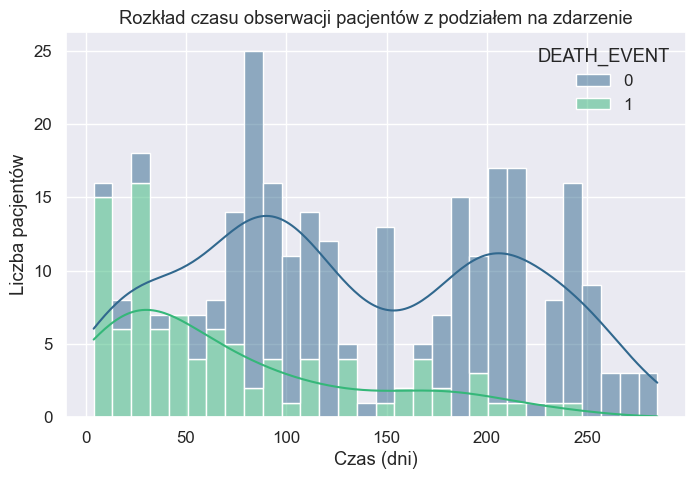

In [9]:
print('\n--- Analiza zdarzenia (DEATH_EVENT) ---')
event_counts = df['DEATH_EVENT'].value_counts()
event_percentages = df['DEATH_EVENT'].value_counts(normalize=True) * 100

print(f'Liczba zgonów (zdarzenie = 1): {event_counts[1]} ({event_percentages[1]:.1f}%)')
print(f'Liczba obserwacji cenzurowanych (zdarzenie = 0): {event_counts[0]} ({event_percentages[0]:.1f}%)')

## Wizualizacja rozkładu zmiennej DEATH_EVENT
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='DEATH_EVENT', palette='viridis')
plt.title('Rozkład zdarzeń (0 = Cenzurowane, 1 = Zgon)')
plt.ylabel('Liczba pacjentów')
plt.show()

## Wizualizacja rozkładu zmiennej DEATH_EVENT w czasie
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='time', bins=30, kde=True, hue='DEATH_EVENT', palette='viridis', multiple='stack')
plt.title('Rozkład czasu obserwacji pacjentów z podziałem na zdarzenie')
plt.xlabel('Czas (dni)')
plt.ylabel('Liczba pacjentów')
plt.show()

## ANALIZA ZMIENNYCH OBJAŚNIAJĄCYCH


--- Korelacje zmiennych z czasem przeżycia ---


,Zmienna,Korelacja z czasem przeżycia
0,serum_sodium,0.08764
1,ejection_fraction,0.04173
2,diabetes,0.03373
3,platelets,0.01051
4,creatinine_phosphokinase,-0.00935
5,sex,-0.01561
6,smoking,-0.02284
7,anaemia,-0.14141
8,serum_creatinine,-0.14932
9,high_blood_pressure,-0.19644


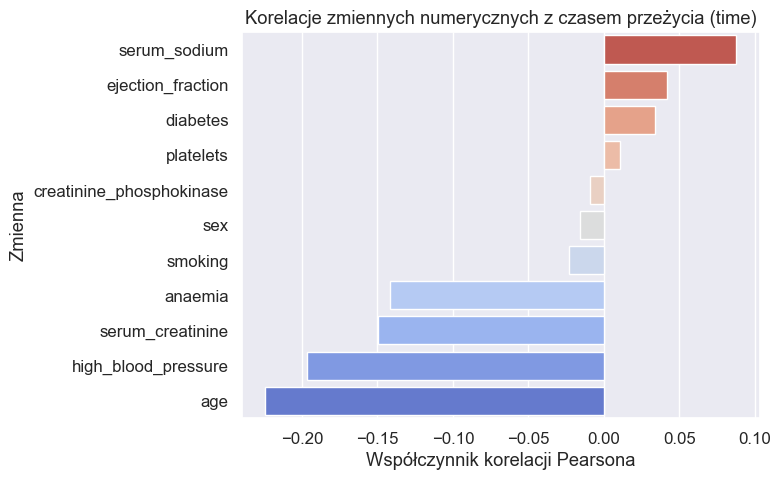

In [21]:
# Przygotowanie zestawu zmiennych: Pearson ma sens tylko dla zmiennych numerycznych
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
to_drop = ['time', 'DEATH_EVENT']
correlations = df[numeric_cols].corr()['time'].sort_values(ascending=False)
# zrzucenie time i DEATH_EVENT z naszej bazy pod korelacje
correlations = correlations.drop(labels=[c for c in to_drop if c in correlations.index])

print('\n--- Korelacje zmiennych z czasem przeżycia ---')
correlations_df = correlations.reset_index()
correlations_df.columns = ['Zmienna', 'Korelacja z czasem przeżycia']
display(correlations_df.style.background_gradient(cmap='coolwarm', subset=['Korelacja z czasem przeżycia']).format({'Korelacja z czasem przeżycia': '{:.5f}'}))

# Wykres korelacji zmiennych z 'time'
plt.figure(figsize=(8, 5))
sns.barplot(
    data=correlations_df,
    y='Zmienna',
    x='Korelacja z czasem przeżycia',
    palette='coolwarm_r',
    orient='h',
    hue='Zmienna',
    legend=False
)
plt.title('Korelacje zmiennych numerycznych z czasem przeżycia (time)')
plt.xlabel('Współczynnik korelacji Pearsona')
plt.ylabel('Zmienna')
plt.tight_layout()
plt.show()



--- Macierz korelacji zmiennych objaśniających


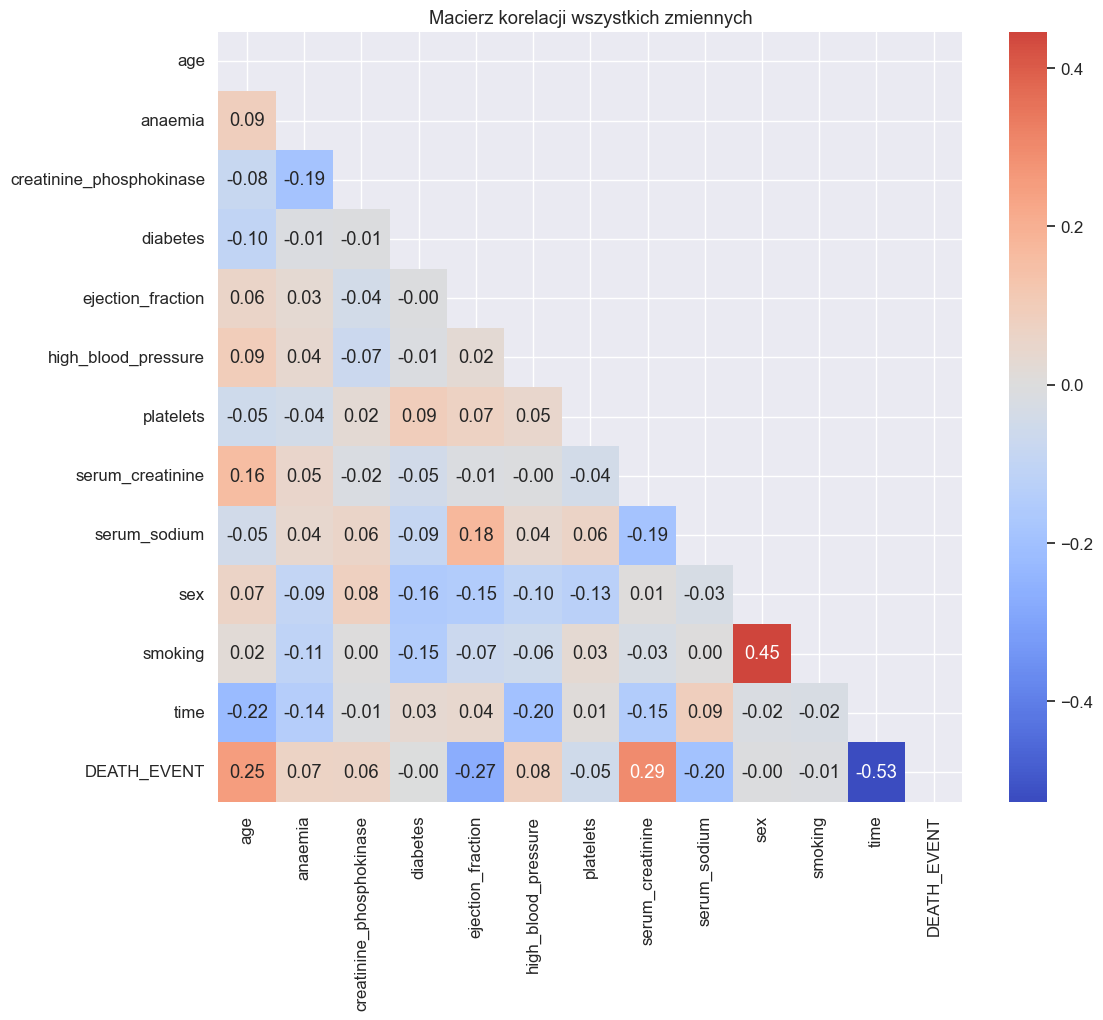

In [ ]:
print('\n--- Macierz korelacji zmiennych objaśniających')

plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Macierz korelacji wszystkich zmiennych')
plt.show()